# Лабораторна робота №2. Дослідження напівпровідникових стабілітронів

**Мета роботи:** ознайомлення з принципом дії, основними властивостями та застосуванням напівпровідникових стабілітронів; дослідження основних параметрів, прямої та зворотної гілок вольт-амперної характеристики стабілітронів.

У цьому зошиті лабораторна робота виконується шляхом SPICE-моделювання (PySpice + ngspice) — так само, як `Лб3_Біполярні_транзистори.ipynb`. ВАХ стабілітрона на ділянці стабілізації моделюється і обробляється чисельно (замість ручних побудов на графіку з документації), а режим роботи параметричного стабілізатора (рис. 3.10) перевіряється моделюванням схеми.

**У цій версії використовується generic (узагальнена) SPICE-модель стабілітрона**, побудована за паспортними параметрами вашого зразка серії BZX85: напругою стабілізації $U_{ст}$ (вона закодована в назві: `BZX85B5V6` → 5,6 В), тестовим струмом $I_{ст.ном}$ і диференціальним опором $r_{д}$ при цьому струмі. Поки ці параметри не внесено з файлу `BZX85_SERIES.pdf` (Гугл диск дисципліни), використовуються **орієнтовні типові** значення для стабілітронів класу 1–1,3 Вт, і зошит про це попереджає. Після внесення паспортних даних усі розрахунки перераховуються автоматично.

## Короткі теоретичні відомості

**Стабілітрон** — напівпровідниковий діод, напруга на якому в області електричного пробою слабо залежить від струму. У низьковольтних стабілітронах ($U_{ст}\lesssim 5$ В) переважає **тунельний** пробій, у високовольтних ($U_{ст}\gtrsim 7$ В) — **лавинний**, у проміжній області діють обидва механізми.

Основні параметри (рис. 3.7, 3.8): напруга стабілізації $U_{ст}$ при номінальному струмі $I_{ст.ном}$; мінімальний $I_{ст.min}$ і максимальний $I_{ст.max}=P_{max}/U_{ст}$ струми стабілізації; **диференціальний опір**

$$r_д = \frac{\Delta U_{ст}}{\Delta I_{ст}};$$

**температурний коефіцієнт напруги стабілізації** $\alpha_{ст}=\dfrac{1}{U_{ст}}\dfrac{dU_{ст}}{dT}$, %/°C — від'ємний для тунельного пробою, додатний для лавинного.

**Параметричний стабілізатор** (рис. 3.10): $U_{in}$ → баластний резистор $R_1$ → стабілітрон VD1 паралельно з навантаженням $R_н$ (і конденсатором $C_1$). За першим законом Кірхгофа

$$I_{R1}=\frac{U_{in}-U_{ст}}{R_1}, \qquad I_н=\frac{U_{ст}}{R_н}, \qquad I_{ст}=I_{R1}-I_н .$$

Стабілізація можлива лише поки $I_{ст.min}\le I_{ст}\le I_{ст.max}$, звідки допустимий діапазон вхідної напруги:

$$U_{in.min}=U_{ст}+R_1\left(I_{ст.min}+\frac{U_{ст}}{R_н}\right), \qquad U_{in.max}=U_{ст}+R_1\left(I_{ст.max}+\frac{U_{ст}}{R_н}\right).$$

**Таблиця 3.1 — Варіанти завдань** (варіант визначається порядковим номером у списку групи):

| № вар. | $U_{in}$, В | $R_1$, Ом | VD1 | $R_н$, Ом | Зразок діода |
|---|---|---|---|---|---|
| 1 | 5 | 47 | КС133А | 160 | BZX85B5V6 |
| 2 | 15 | 680 | КС211Ж | 3600 | BZX85B12 |
| 3 | 5 | 15 | КС439А | 100 | BZX85B3V9 |
| 4 | 50 | 2700 | КС531В | 7500 | BZX85B33 |
| 5 | 150 | 1500 | КС620А | 12 кОм | BZX85B47 |
| 6 | 12 | 560 | 2С182Ж | 2000 | BZX85B8V2 |
| 7 | 15 | 620 | 2С212Ц | 3900 | BZX85B12 |
| 8 | 12 | 75 | 2С482А | 430 | BZX85B8V2 |
| 9 | 20 | 200 | 2С515А | 1500 | BZX85B15 |
| 10 | 130 | 7500 | 2С600А | 47 кОм | BZX85B39 |
| 11 | 9 | 220 | КС168В | 1300 | BZX85B6V8 |
| 12 | 15 | 560 | КС212Ж | 3900 | BZX85B18 |
| 13 | 10 | 51 | КС468А | 240 | BZX85B6V8 |
| 14 | 50 | 2200 | КС533А | 8200 | BZX85B27 |
| 15 | 200 | 1500 | КС680А | 27 кОм | BZX85B47 |
| 16 | 12 | 300 | 2С191С | 1800 | BZX85B10 |
| 17 | 15 | 390 | 2С213Б | 13 кОм | BZX85B15 |
| 18 | 6 | 16 | 2С447А | 120 | BZX85B4V7 |
| 19 | 30 | 390 | 2С522А | 2200 | BZX85B22 |
| 20 | 9 | 62 | 2С147А | 180 | BZX85B4V7 |

У розрахунках схеми в якості VD1 використовується ваш **зразок діода** серії BZX85 — саме для нього є документація.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

import schemdraw
import schemdraw.elements as elm
elm.style(elm.STYLE_IEC)   # умовні позначення за ДСТУ/IEC (резистор — прямокутник)

%matplotlib inline

/home/bp/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Вихідні дані варіанту

In [2]:
VARIANT = 9   # <-- ваш варіант (1..20)

#      Uin, В  R1, Ом  VD1         Rн, Ом   Зразок діода
VARIANTS = {
    1:  (5,    47,    'КС133А',    160,    'BZX85B5V6'),
    2:  (15,   680,   'КС211Ж',    3600,   'BZX85B12'),
    3:  (5,    15,    'КС439А',    100,    'BZX85B3V9'),
    4:  (50,   2700,  'КС531В',    7500,   'BZX85B33'),
    5:  (150,  1500,  'КС620А',    12e3,   'BZX85B47'),
    6:  (12,   560,   '2С182Ж',    2000,   'BZX85B8V2'),
    7:  (15,   620,   '2С212Ц',    3900,   'BZX85B12'),
    8:  (12,   75,    '2С482А',    430,    'BZX85B8V2'),
    9:  (20,   200,   '2С515А',    1500,   'BZX85B15'),
    10: (130,  7500,  '2С600А',    47e3,   'BZX85B39'),
    11: (9,    220,   'КС168В',    1300,   'BZX85B6V8'),
    12: (15,   560,   'КС212Ж',    3900,   'BZX85B18'),
    13: (10,   51,    'КС468А',    240,    'BZX85B6V8'),
    14: (50,   2200,  'КС533А',    8200,   'BZX85B27'),
    15: (200,  1500,  'КС680А',    27e3,   'BZX85B47'),
    16: (12,   300,   '2С191С',    1800,   'BZX85B10'),
    17: (15,   390,   '2С213Б',    13e3,   'BZX85B15'),
    18: (6,    16,    '2С447А',    120,    'BZX85B4V7'),
    19: (30,   390,   '2С522А',    2200,   'BZX85B22'),
    20: (9,    62,    '2С147А',    180,    'BZX85B4V7'),
}

Uin, R1, VD1_OLD, Rn, ZENER = VARIANTS[VARIANT]
Vz_nom = float(ZENER.replace('BZX85B', '').replace('V', '.'))   # 'BZX85B5V6' -> 5.6 В
print(f'Варіант {VARIANT}: Uin = {Uin} В, R1 = {R1} Ом, Rн = {Rn:g} Ом, VD1 = {ZENER} (Uст = {Vz_nom} В; у старій таблиці — {VD1_OLD})')

Варіант 9: Uin = 20 В, R1 = 200 Ом, Rн = 1500 Ом, VD1 = BZX85B15 (Uст = 15.0 В; у старій таблиці — 2С515А)


### Паспортні дані стабілітрона

Знайдіть у файлі `BZX85_SERIES.pdf` для свого зразка і занесіть сюди (якщо значення невідоме — залиште `None`, буде використано типове):

* `Izt` — тестовий (номінальний) струм стабілізації $I_{ст.ном}$, А;
* `rzt` — диференціальний опір при $I_{ст.ном}$, Ом;
* `Iz_min` — мінімальний струм стабілізації, А (струм на «коліні» ВАХ, при якому нормується $r_{д}$ на початку ділянки пробою);
* `P_max` — максимальна потужність розсіювання, Вт;
* `alpha_z` — температурний коефіцієнт напруги стабілізації, %/°C.

In [3]:
# TODO: підставте паспортні дані СВОГО стабілітрона (BZX85_SERIES.pdf)
Izt = None        # А
rzt = None        # Ом
Iz_min = None     # А
P_max = None      # Вт
alpha_z = None    # %/°C

In [4]:
# Орієнтовні типові значення для стабілітронів класу 1–1,3 Вт (використовуються, лише якщо паспортні дані не внесено).
#   Uст, В : (Iст.ном, А, rд, Ом, αст, %/°C)
TYPICAL = {3.9: (64e-3, 9, -0.05),   4.7: (53e-3, 8, -0.02),   5.6: (45e-3, 5, 0.02),
           6.8: (37e-3, 3.5, 0.045), 8.2: (31e-3, 4.5, 0.06),  10: (25e-3, 7, 0.07),
           12: (21e-3, 9, 0.075),    15: (17e-3, 14, 0.08),    18: (14e-3, 20, 0.085),
           22: (11.5e-3, 23, 0.09),  27: (9.5e-3, 35, 0.09),   33: (7.5e-3, 45, 0.09),
           39: (6.5e-3, 60, 0.09),   47: (5.5e-3, 80, 0.09)}

used_typical = []
def pick(value, typical, name):
    if value is None:
        used_typical.append(name)
        return typical
    return value

izt_t, rzt_t, alpha_t = TYPICAL[Vz_nom]
IZT = pick(Izt, izt_t, 'Izt')
RZT = pick(rzt, rzt_t, 'rzt')
IZ_MIN = pick(Iz_min, 1e-3, 'Iz_min')
PMAX = pick(P_max, 1.3, 'P_max')
ALPHA = pick(alpha_z, alpha_t, 'alpha_z')
IZ_MAX = PMAX / Vz_nom

if used_typical:
    print('Увага: використано ОРІЄНТОВНІ типові значення для', ', '.join(used_typical),
          '— замініть паспортними даними з BZX85_SERIES.pdf!')
print(f'Uст = {Vz_nom} В при Iст.ном = {IZT*1e3:g} мА;  rд = {RZT} Ом;  '
      f'Iст.min = {IZ_MIN*1e3:g} мА;  Iст.max = Pmax/Uст = {IZ_MAX*1e3:.1f} мА;  αст = {ALPHA:+.3f} %/°C')

Увага: використано ОРІЄНТОВНІ типові значення для Izt, rzt, Iz_min, P_max, alpha_z — замініть паспортними даними з BZX85_SERIES.pdf!
Uст = 15.0 В при Iст.ном = 17 мА;  rд = 14 Ом;  Iст.min = 1 мА;  Iст.max = Pmax/Uст = 86.7 мА;  αст = +0.080 %/°C


## Модель стабілітрона

Зворотна гілка SPICE-моделі діода в області пробою описується виразом

$$U = BV + NBV\cdot\varphi_T \ln\frac{I}{IBV} + I\cdot RS,$$

тому її диференціальний опір $r_д = NBV\cdot\varphi_T/I + RS$ зменшується зі зростанням струму — як у реальних стабілітронів (рис. 3.7). Параметри підбираються так, щоб при $I_{ст.ном}$ напруга дорівнювала $U_{ст}$, а диференціальний опір — паспортному $r_{д}$ (70 % якого припадає на «м'якість» пробою `NBV`, решта — на омічний опір `RS`; для низьковольтних стабілітронів `NBV` обмежується так, щоб на ділянці $I_{ст.min}\ldots I_{ст.ном}$ напруга змінювалась не більш ніж на 15 %).

**Важливо (типова пастка ngspice):** параметр `TCV` (температурний коефіцієнт напруги пробою) у ngspice має розмірність В/°C і **протилежний знак**: $BV(T)=BV-TCV\,(T-T_{ном})$. Тому для стабілітрона з $\alpha_{ст}>0$ потрібно задавати `TCV < 0`. Як і в Лб3, струми й напруги задаються звичайними числами в амперах і вольтах.

In [5]:
PHI_T = 1.380649e-23 * 298.15 / 1.602176634e-19   # В, тепловий потенціал при 25 °C

# «м'якість» пробою: 70 % rд, але так, щоб на ділянці Iст.min…Iст.ном Uст змінювалась не більш ніж на 15 %
L_Z = np.log(IZT / IZ_MIN) - (1 - IZ_MIN / IZT)
NBV_lim = max(0.15 * Vz_nom - RZT * (IZT - IZ_MIN), 0) / (PHI_T * L_Z)
NBV_Z = min(0.7 * RZT * IZT / PHI_T, NBV_lim)
RS_Z = RZT - NBV_Z * PHI_T / IZT
ZENER_PARAMS = dict(IS=1e-14, N=1, RS=RS_Z,
                    BV=Vz_nom - RS_Z * IZT, IBV=IZT,
                    NBV=NBV_Z,
                    TCV=-ALPHA / 100 * Vz_nom)       # знак мінус — див. пастку вище


def add_zener(circuit, anode, cathode):
    circuit.model('DZ', 'D', **ZENER_PARAMS)
    circuit.D('Z', anode, cathode, model='DZ')


def zener_reverse_iv(i_max, temperature=25, n_points=2000):
    """Зворотна гілка (ділянка стабілізації): струм IZ втікає в катод."""
    circuit = Circuit('Zener reverse IV')
    circuit.I('Z', circuit.gnd, 'cathode', 0)
    add_zener(circuit, circuit.gnd, 'cathode')
    simulator = circuit.simulator(temperature=temperature, nominal_temperature=25)
    analysis = simulator.dc(IZ=slice(0, i_max, i_max / n_points))
    return np.array(analysis.sweep), np.array(analysis.cathode)


def zener_forward_iv(i_max=0.2, n_points=500):
    circuit = Circuit('Zener forward IV')
    circuit.I('F', circuit.gnd, 'anode', 0)
    add_zener(circuit, 'anode', circuit.gnd)
    analysis = circuit.simulator(temperature=25, nominal_temperature=25).dc(IF=slice(0, i_max, i_max / n_points))
    return np.array(analysis.sweep), np.array(analysis.anode)


def make_stabilizer(uin, r1, rn, c1=None, ac=False):
    """Параметричний стабілізатор (рис. 3.10)."""
    circuit = Circuit('Parametric stabilizer')
    circuit.V('IN', 'inp', circuit.gnd, f'DC {uin} AC 1' if ac else uin)
    circuit.R(1, 'inp', 'out', r1)
    add_zener(circuit, circuit.gnd, 'out')
    circuit.R('N', 'out', circuit.gnd, rn)
    if c1:
        circuit.C(1, 'out', circuit.gnd, c1)
    return circuit


def stabilizer_op(uin, r1, rn, temperature=25):
    """Робоча точка: Uвих, I_R1, I_н, I_ст."""
    circuit = make_stabilizer(uin, r1, rn)
    analysis = circuit.simulator(temperature=temperature, nominal_temperature=25).operating_point()
    u_out = float(np.array(analysis.out)[0])
    i_r1, i_n = (uin - u_out) / r1, u_out / rn
    return u_out, i_r1, i_n, i_r1 - i_n


print('Параметри моделі:', ', '.join(f'{k}={v:.4g}' for k, v in ZENER_PARAMS.items()))

Параметри моделі: IS=1e-14, N=1, RS=4.2, BV=14.93, IBV=0.017, NBV=6.484, TCV=-0.012


## Проведення дослідження

### 1. ВАХ стабілітрона (рис. 3.4)

Пряма гілка — звичайний кремнієвий діод; зворотна — різкий пробій при $U\approx U_{ст}$. Робоча ділянка стабілізації обмежена струмами $I_{ст.min}$ та $I_{ст.max}$.

Unsupported Ngspice version 42


Using SPARSE 1.3 as Direct Linear Solver


Using SPARSE 1.3 as Direct Linear Solver


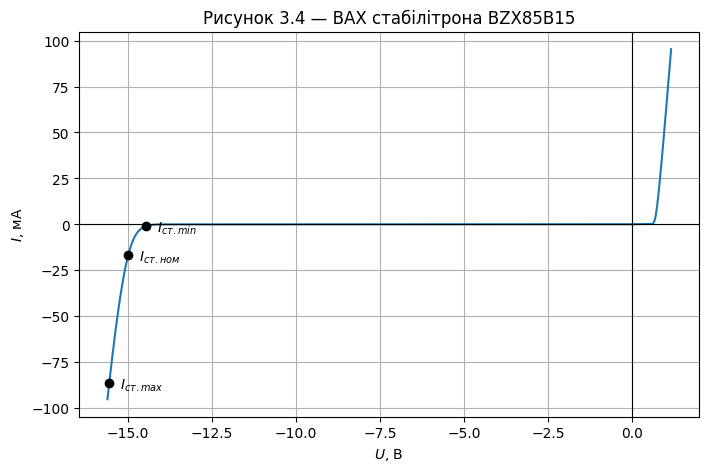

In [6]:
I_rev, V_rev = zener_reverse_iv(i_max=1.1 * IZ_MAX)
I_fwd, V_fwd = zener_forward_iv(i_max=1.1 * IZ_MAX)

plt.figure(figsize=(8, 5))
plt.plot(V_fwd, I_fwd * 1e3, 'C0')
plt.plot(-V_rev, -I_rev * 1e3, 'C0')
for i_, name in [(IZ_MIN, '$I_{ст.min}$'), (IZT, '$I_{ст.ном}$'), (IZ_MAX, '$I_{ст.max}$')]:
    u_ = np.interp(i_, I_rev, V_rev)
    plt.plot(-u_, -i_ * 1e3, 'ko')
    plt.annotate(name, (-u_, -i_ * 1e3), textcoords='offset points', xytext=(8, -4))
plt.axhline(0, color='k', lw=0.8); plt.axvline(0, color='k', lw=0.8)
plt.xlabel('$U$, В'); plt.ylabel('$I$, мА')
plt.title(f'Рисунок 3.4 — ВАХ стабілітрона {ZENER}')
plt.grid(True)
plt.show()

### 2. Диференціальний опір і середня напруга стабілізації (рис. 3.9)

ВАХ на ділянці стабілізації перебудовано у звичайному (лінійному) масштабі з віссю струму вгору — як на рис. 3.9. Диференціальний опір визначається для трьох струмів — мінімального, номінального та максимального — як котангенс кута нахилу дотичної (чисельно: центральна різниця двох сусідніх точок густої розгортки — аналог двох курсорів). Середня напруга стабілізації — середнє значення напруги на робочій ділянці $I_{ст.min}\ldots I_{ст.max}$.

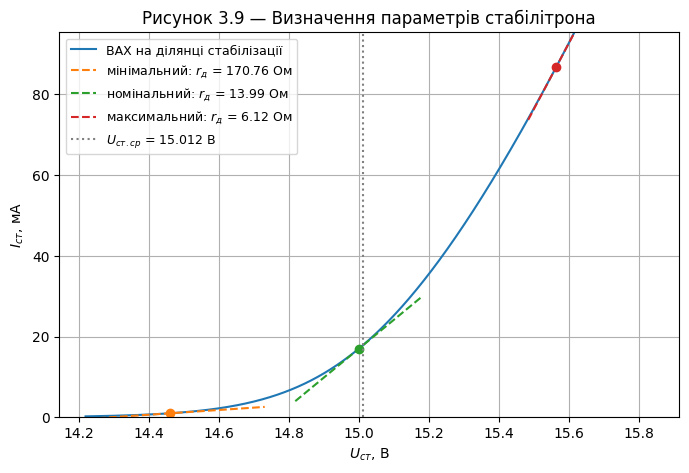

Середня напруга стабілізації Uст.ср = 15.012 В


,"Iст, мА","Uст, В","rд, Ом"
мінімальний,1.000000,14.460958,170.757259
номінальний,17.000000,15.000238,13.990232
максимальний,86.666667,15.563914,6.122499


In [7]:
def diff_resistance(i0):
    """r_д = dU/dI поблизу i0 — метод двох курсорів на одній кривій."""
    idx = int(np.argmin(np.abs(I_rev - i0)))
    i0_, i1_ = max(idx - 1, 0), min(idx + 1, len(I_rev) - 1)
    return (V_rev[i1_] - V_rev[i0_]) / (I_rev[i1_] - I_rev[i0_]), V_rev[idx]


points = {'мінімальний': IZ_MIN, 'номінальний': IZT, 'максимальний': IZ_MAX}
rows = {}
for name, i0 in points.items():
    rd, u0 = diff_resistance(i0)
    rows[name] = {'Iст, мА': i0 * 1e3, 'Uст, В': u0, 'rд, Ом': rd}
table_rd = pd.DataFrame(rows).T

U_avg = (np.interp(IZ_MIN, I_rev, V_rev) + np.interp(IZ_MAX, I_rev, V_rev)) / 2   # середина робочої ділянки

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(V_rev[I_rev > 0.2 * IZ_MIN], I_rev[I_rev > 0.2 * IZ_MIN] * 1e3, label='ВАХ на ділянці стабілізації')
for (name, i0), col in zip(points.items(), ('C1', 'C2', 'C3')):
    rd, u0 = diff_resistance(i0)
    di = min(0.15 * IZ_MAX, 0.06 * Vz_nom * 0.1 / rd * 3)   # відрізок дотичної обмеженої довжини
    ax.plot([u0 - rd * di, u0 + rd * di], [(i0 - di) * 1e3, (i0 + di) * 1e3], '--', color=col,
            label=f'{name}: $r_д$ = {rd:.2f} Ом')
    ax.plot(u0, i0 * 1e3, 'o', color=col)
ax.axvline(U_avg, color='gray', ls=':', label=f'$U_{{ст.ср}}$ = {U_avg:.3f} В')
ax.set_ylim(0, 1.1 * IZ_MAX * 1e3)
ax.set_xlim(V_rev[I_rev > 0.2 * IZ_MIN][0] - 0.05 * Vz_nom * 0.1, V_rev[-1] + 0.02 * Vz_nom)
ax.set_xlabel('$U_{ст}$, В'); ax.set_ylabel('$I_{ст}$, мА')
ax.set_title('Рисунок 3.9 — Визначення параметрів стабілітрона')
ax.legend(fontsize=9); ax.grid(True)
plt.show()

print(f'Середня напруга стабілізації Uст.ср = {U_avg:.3f} В')
table_rd

### 3. Аналіз режиму стабілітрона в параметричному стабілізаторі (рис. 3.10)

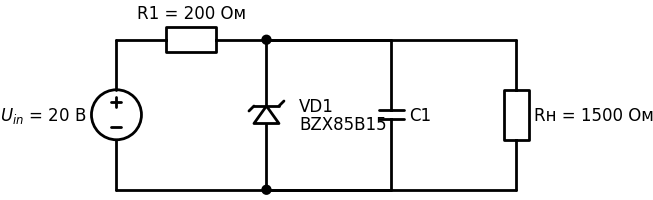

In [8]:
with schemdraw.Drawing() as d:
    d.config(fontsize=12, unit=3)
    src = elm.SourceV().up().label(f'$U_{{in}}$ = {Uin:g} В')
    elm.Resistor().right().label(f'R1 = {R1:g} Ом')
    top = elm.Dot()
    elm.Zener().down().reverse().label(f'VD1\n{ZENER}', loc='bottom', ofst=0.3)
    bot = elm.Dot()
    elm.Line().left().tox(src.start)
    elm.Line().at(top.center).right(2.5)
    elm.Capacitor().down().label('C1', loc='bottom')
    elm.Line().left().tox(bot.center)
    elm.Line().at(top.center).right(5)
    elm.Resistor().down().label(f'Rн = {Rn:g} Ом', loc='bottom')
    elm.Line().left().tox(bot.center)

In [9]:
# --- ручний розрахунок ---
U_div = Uin * Rn / (R1 + Rn)          # напруга на Rн, якби стабілітрона не було
if U_div > Vz_nom:                    # стабілітрон пробитий: Uвих = Uст
    I_R1_calc = (Uin - Vz_nom) / R1
    I_n_calc = Vz_nom / Rn
else:                                 # стабілітрон закритий: працює лише дільник R1-Rн
    print(f'Uin·Rн/(R1+Rн) = {U_div:.2f} В < Uст = {Vz_nom} В — стабілітрон не пробивається.')
    I_R1_calc = I_n_calc = Uin / (R1 + Rn)
I_z_calc = I_R1_calc - I_n_calc

# --- SPICE ---
U_out, I_R1, I_n, I_z = stabilizer_op(Uin, R1, Rn)
P_R1, P_Rn, P_VD = I_R1 ** 2 * R1, U_out ** 2 / Rn, U_out * I_z

print(f'Ручний розрахунок:  I_R1 = {I_R1_calc*1e3:.2f} мА,  Iн = {I_n_calc*1e3:.2f} мА,  Iст = {I_z_calc*1e3:.2f} мА')
print(f'SPICE:              I_R1 = {I_R1*1e3:.2f} мА,  Iн = {I_n*1e3:.2f} мА,  Iст = {I_z*1e3:.2f} мА,  Uвих = {U_out:.3f} В')
print(f'Потужності:  P_R1 = {P_R1*1e3:.1f} мВт,  P_Rн = {P_Rn*1e3:.1f} мВт,  P_VD1 = {P_VD*1e3:.1f} мВт  (Pmax = {PMAX*1e3:g} мВт)')

if I_z < IZ_MIN:
    print(f'\nУВАГА: Iст = {I_z*1e3:.3f} мА < Iст.min = {IZ_MIN*1e3:g} мА — стабілітрон не перебуває в режимі '
          f'стабілізації, напруга на навантаженні визначається дільником R1–Rн: Uвих = {U_out:.3f} В.')
elif I_z > IZ_MAX:
    print(f'\nУВАГА: Iст = {I_z*1e3:.1f} мА > Iст.max = {IZ_MAX*1e3:.1f} мА — потужність на стабілітроні '
          f'{P_VD:.2f} Вт перевищує допустиму {PMAX} Вт (тепловий пробій)!')
else:
    print('\nСтабілітрон працює в допустимому режимі стабілізації.')

Using SPARSE 1.3 as Direct Linear Solver


Ручний розрахунок:  I_R1 = 25.00 мА,  Iн = 10.00 мА,  Iст = 15.00 мА
SPICE:              I_R1 = 25.13 мА,  Iн = 9.98 мА,  Iст = 15.15 мА,  Uвих = 14.973 В
Потужності:  P_R1 = 126.3 мВт,  P_Rн = 149.5 мВт,  P_VD1 = 226.9 мВт  (Pmax = 1300 мВт)

Стабілітрон працює в допустимому режимі стабілізації.


### 4. Допустимий діапазон зміни вхідної напруги

Аналітичні межі $U_{in.min}$, $U_{in.max}$ (див. теорію) перевіряються розгорткою $U_{in}$: у межах заштрихованої області напруга на виході майже не змінюється, а струм стабілітрона лежить між $I_{ст.min}$ та $I_{ст.max}$.

Using SPARSE 1.3 as Direct Linear Solver


Допустимий діапазон вхідної напруги: Uin = 16.59 ... 34.97 В   (за варіантом Uin = 20 В)


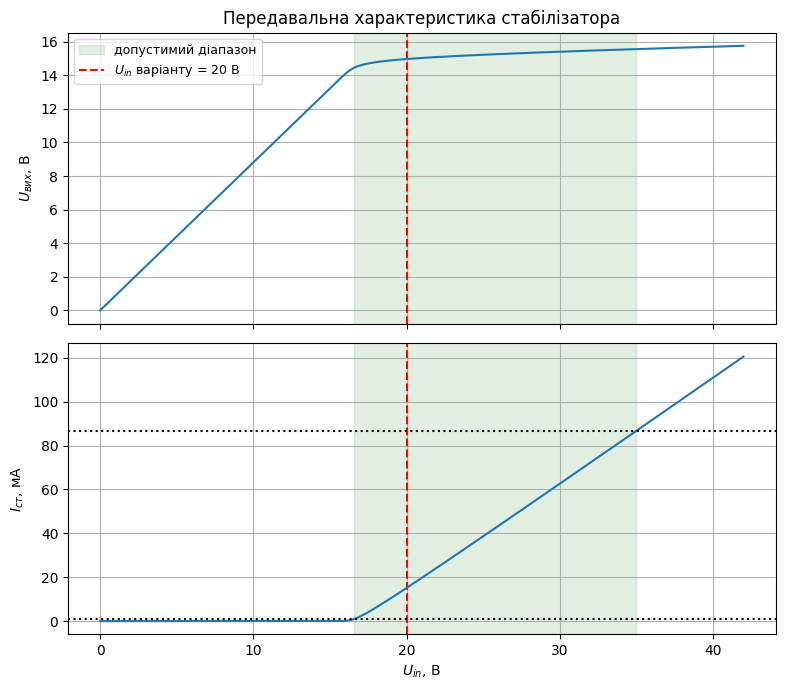

Коефіцієнт стабілізації Kст = (ΔUin/Uin)/(ΔUвих/Uвих) ~= 12.8


In [10]:
Vz_at_min = np.interp(IZ_MIN, I_rev, V_rev)
Vz_at_max = np.interp(IZ_MAX, I_rev, V_rev)
Uin_min = Vz_at_min + R1 * (IZ_MIN + Vz_at_min / Rn)
Uin_max = Vz_at_max + R1 * (IZ_MAX + Vz_at_max / Rn)
print(f'Допустимий діапазон вхідної напруги: Uin = {Uin_min:.2f} ... {Uin_max:.2f} В   (за варіантом Uin = {Uin} В)')

u_hi = 1.2 * max(Uin_max, Uin)
circuit = make_stabilizer(0, R1, Rn)
analysis = circuit.simulator(temperature=25, nominal_temperature=25).dc(VIN=slice(0, u_hi, u_hi / 1000))
uin_s, uout_s = np.array(analysis.sweep), np.array(analysis.out)
iz_s = (uin_s - uout_s) / R1 - uout_s / Rn

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
for ax in axes:
    ax.axvspan(Uin_min, Uin_max, color='g', alpha=0.12, label='допустимий діапазон')
    ax.axvline(Uin, color='r', ls='--', label=f'$U_{{in}}$ варіанту = {Uin} В')
    ax.grid(True)
axes[0].plot(uin_s, uout_s)
axes[0].set_ylabel('$U_{вих}$, В'); axes[0].legend(fontsize=9)
axes[0].set_title('Передавальна характеристика стабілізатора')
axes[1].plot(uin_s, iz_s * 1e3)
axes[1].axhline(IZ_MIN * 1e3, color='k', ls=':'); axes[1].axhline(IZ_MAX * 1e3, color='k', ls=':')
axes[1].set_ylabel('$I_{ст}$, мА'); axes[1].set_xlabel('$U_{in}$, В')
plt.tight_layout()
plt.show()

in_band = (uin_s >= Uin_min) & (uin_s <= Uin_max)
if in_band.sum() > 2:
    k_st = ((uin_s[in_band][-1] - uin_s[in_band][0]) / Uin) / ((uout_s[in_band][-1] - uout_s[in_band][0]) / uout_s[in_band].mean())
    print(f'Коефіцієнт стабілізації Kст = (ΔUin/Uin)/(ΔUвих/Uвих) ~= {k_st:.1f}')

### 5. Вплив температури: нагрів стабілітрона з 25 °C до 50 °C

Напруга стабілізації змінюється на $\Delta U_{ст}\approx \alpha_{ст} U_{ст}\Delta T$. Знак $\alpha_{ст}$ визначається механізмом пробою: при **тунельному** пробої (низьковольтні стабілітрони) з ростом температури зменшується ширина забороненої зони і напруга пробою **зменшується** ($\alpha_{ст}<0$); при **лавинному** — зменшується довжина вільного пробігу носіїв (розсіювання на коливаннях ґратки), для ударної іонізації потрібне сильніше поле і напруга пробою **зростає** ($\alpha_{ст}>0$).

Using SPARSE 1.3 as Direct Linear Solver


Using SPARSE 1.3 as Direct Linear Solver


Using SPARSE 1.3 as Direct Linear Solver


Using SPARSE 1.3 as Direct Linear Solver


Using SPARSE 1.3 as Direct Linear Solver


Uвих(25 °C) = 14.9731 В,  Uвих(50 °C) = 15.2456 В,  ΔUвих = +272.5 мВ
Оцінка α·Uст·ΔT = +300.0 мВ;  лавинний пробій переважає (α > 0)


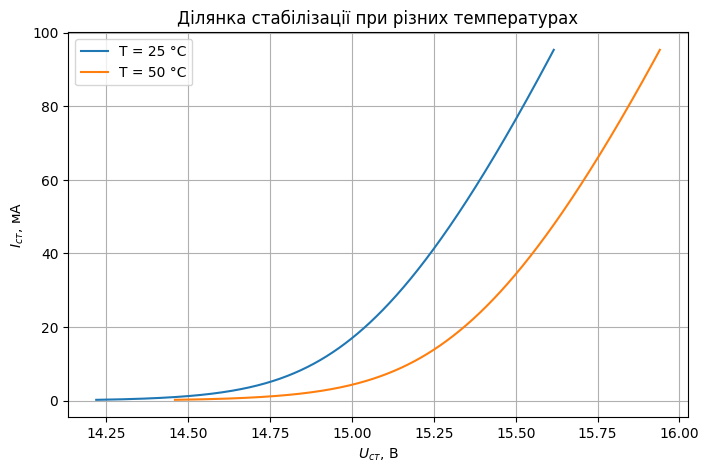

In [11]:
U_out_25 = stabilizer_op(Uin, R1, Rn, temperature=25)[0]
U_out_50 = stabilizer_op(Uin, R1, Rn, temperature=50)[0]
print(f'Uвих(25 °C) = {U_out_25:.4f} В,  Uвих(50 °C) = {U_out_50:.4f} В,  ΔUвих = {(U_out_50 - U_out_25)*1e3:+.1f} мВ')
if stabilizer_op(Uin, R1, Rn)[3] < IZ_MIN:
    print('Стабілітрон вашого варіанту не в режимі стабілізації — Uвих задається дільником R1–Rн і від αст не залежить.')
print(f'Оцінка α·Uст·ΔT = {ALPHA/100 * Vz_nom * 25 * 1e3:+.1f} мВ;  '
      + ('тунельний пробій переважає (α < 0)' if ALPHA < 0 else 'лавинний пробій переважає (α > 0)'))

plt.figure(figsize=(8, 5))
for T in (25, 50):
    i_t, v_t = zener_reverse_iv(i_max=1.1 * IZ_MAX, temperature=T)
    m = i_t > 0.2 * IZ_MIN
    plt.plot(v_t[m], i_t[m] * 1e3, label=f'T = {T} °C')
plt.xlabel('$U_{ст}$, В'); plt.ylabel('$I_{ст}$, мА')
plt.title('Ділянка стабілізації при різних температурах')
plt.legend(); plt.grid(True)
plt.show()

### 6. Призначення конденсатора $C_1$

Для змінної складової вхідної напруги (пульсації, завади) стабілізатор — дільник $R_1$ і паралельно ввімкнених $r_д$, $R_н$. Конденсатор $C_1$ додатково шунтує вихід на високих частотах: він **придушує шуми пробою** стабілітрона (лавинний пробій — потужне джерело широкосмугового шуму) і високочастотні завади, а також знижує вихідний опір для імпульсних змін струму навантаження. Без $C_1$ на високих частотах ці складові потрапляють у навантаження без додаткового ослаблення. На низьких частотах (наприклад, 100 Гц пульсацій випрямляча) ослаблення визначає лише відношення $R_1/r_д$. Номінал $C_1$ у завданні не задано — нижче порівняно кілька значень.

Using SPARSE 1.3 as Direct Linear Solver


Using SPARSE 1.3 as Direct Linear Solver


Using SPARSE 1.3 as Direct Linear Solver


Using SPARSE 1.3 as Direct Linear Solver


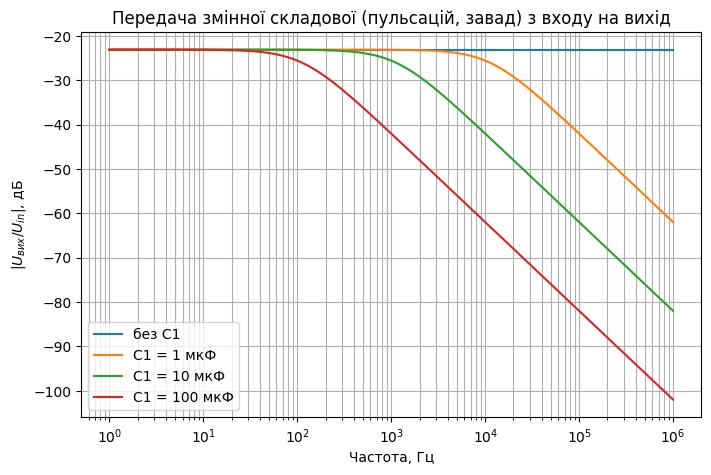

In [12]:
plt.figure(figsize=(8, 5))
for c1 in (None, 1e-6, 10e-6, 100e-6):
    circuit = make_stabilizer(Uin, R1, Rn, c1=c1, ac=True)
    analysis = circuit.simulator(temperature=25, nominal_temperature=25).ac(
        start_frequency=1@u_Hz, stop_frequency=1@u_MHz, number_of_points=20, variation='dec')
    k = np.abs(np.array(analysis.out))
    plt.semilogx(np.array(analysis.frequency), 20 * np.log10(k),
                 label='без C1' if c1 is None else f'C1 = {c1*1e6:g} мкФ')
plt.xlabel('Частота, Гц'); plt.ylabel('$|U_{вих}/U_{in}|$, дБ')
plt.title('Передача змінної складової (пульсацій, завад) з входу на вихід')
plt.legend(); plt.grid(True, which='both')
plt.show()

## Інтерактивний аналіз режиму стабілізатора

Графічний метод: робоча точка — перетин ВАХ стабілітрона з лінією навантаження еквівалентного джерела $U_{екв}=U_{in}\dfrac{R_н}{R_1+R_н}$, $R_{екв}=R_1\parallel R_н$: $\;I_{ст}=\dfrac{U_{екв}-U}{R_{екв}}$. Змінюйте $U_{in}$ і $R_н$ та спостерігайте, коли стабілітрон виходить з режиму стабілізації.

In [13]:
@interact(Uin_V=widgets.FloatSlider(min=0.5 * Uin, max=2.0 * Uin, step=Uin / 50, value=Uin, description='$U_{in}$, В'),
          Rn_rel=widgets.FloatLogSlider(base=10, min=-1, max=1, step=0.05, value=1, description='$R_н/R_{н.вар}$'))
def explore_stabilizer(Uin_V, Rn_rel):
    rn = Rn * Rn_rel
    u_out, i_r1, i_n, i_z = stabilizer_op(Uin_V, R1, rn)
    u_eq, r_eq = Uin_V * rn / (R1 + rn), R1 * rn / (R1 + rn)

    fig, ax = plt.subplots(figsize=(8, 5))
    m = I_rev > 0
    ax.plot(V_rev[m], I_rev[m] * 1e3, label=f'ВАХ {ZENER}')
    u = np.linspace(0, max(u_eq, Vz_nom) * 1.05, 200)
    ax.plot(u, (u_eq - u) / r_eq * 1e3, 'k--', label='лінія навантаження')
    ax.plot(u_out, max(i_z, 0) * 1e3, 'ro', ms=8)
    ax.axhspan(IZ_MIN * 1e3, IZ_MAX * 1e3, color='g', alpha=0.1, label='$I_{ст.min}…I_{ст.max}$')
    ax.set_xlim(0, max(u_eq, Vz_nom) * 1.05); ax.set_ylim(0, 1.3 * IZ_MAX * 1e3)
    ax.set_xlabel('$U$, В'); ax.set_ylabel('$I_{ст}$, мА')
    ax.legend(fontsize=9); ax.grid(True)
    plt.show()
    print(f'Uвих = {u_out:.3f} В,  Iст = {i_z*1e3:.2f} мА,  P_VD1 = {u_out*max(i_z,0)*1e3:.1f} мВт,  '
          f'P_R1 = {i_r1**2*R1*1e3:.1f} мВт,  P_Rн = {u_out**2/rn*1e3:.1f} мВт')

interactive(children=(FloatSlider(value=20.0, description='$U_{in}$, В', max=40.0, min=10.0, step=0.4), FloatL…

## Висновки

*(заповнюється студентом)*

1. Навести ВАХ свого стабілітрона на ділянці стабілізації з побудовами для визначення диференціального опору при мінімальному, номінальному та максимальному струмах і середньої напруги стабілізації; пояснити, чому $r_д$ зменшується зі зростанням струму.
2. Для схеми параметричного стабілізатора навести струм стабілітрона та потужності на $R_1$, $R_н$ і VD1; зробити висновок, чи перебуває стабілітрон у допустимому режимі (порівняти ручний розрахунок і результат моделювання).
3. Навести допустимий діапазон зміни вхідної напруги $U_{in}$.
4. Пояснити, як зміниться вихідна напруга при нагріві стабілітрона з 25 °C до 50 °C і який механізм пробою (тунельний чи лавинний) це визначає.
5. Пояснити призначення конденсатора $C_1$ і що зміниться, якщо його видалити.

## Контрольні запитання

1. Як позначаються на принципових схемах стабілітрони?
2. Який тип пробою використовується в напівпровідникових стабілітронах?
3. Назвіть основні сфери застосування напівпровідникових стабілітронів.
4. Вкажіть основні причини відмінностей експериментально отриманих зворотних гілок ВАХ від ідеалізованої характеристики.

## Рекомендована література

1. Батушев В. А. Электронные приборы. — М.: Высш. шк., 1980. — 383 с.
2. Васильева Л. Д., Медведенко Б. І., Якименко Ю. І. Напівпровідникові прилади. — К.: ІВЦ «Політехніка», 2003. — 388 с.
3. Колонтаєвський Ю. П., Сосков А. Г. Електроніка і мікросхемотехніка: підручник. — К.: Каравела, 2007. — 384 с.
4. Пасынков В. В., Чиркин Л. К. Полупроводниковые приборы. — М.: Высшая школа, 1987. — 432 с.
5. Тугов Н. М., Глебов Б. А., Чарыков Н. А. Полупроводниковые приборы. — М.: Энергоатомиздат, 1990. — 576 с.
6. Электронные приборы / под ред. Г. Г. Шишкина. — М.: Энергоатомиздат, 1989. — 496 с.
7. Алехин В. А. Электротехника и электроника. Компьютерный лабораторный практикум в программной среде TINA-8. — М.: Горячая линия — Телеком, 2014. — 208 с.